In [1]:
import numpy as np
import pandas as pd

# Data #

In [4]:
rights_df = pd.read_csv('https://raw.githubusercontent.com/Tahvia127/s26-geography-of-rights/refs/heads/main/master_scored.csv')
rights_df.head(10)

,State,1.1,1.2,1.3,1.4,1.5,1.6,2.1,2.2,2.3,...,P3,P4,P5,P6,P7,P8,P9,P10,Rank_EqualWeight,Rank_PCA
0,Alabama,0,50,0,0,0,0,-10.25,0,0,...,59.0,63.1,26.6,4.8,0.4847,3.0,1,R,49,49
1,Alaska,100,100,100,0,0,100,8.50,50,0,...,66.0,58.8,3.2,7.5,0.4220,5.2,1,R,21,21
2,Arizona,80,100,100,100,100,0,5.75,50,0,...,89.8,53.4,5.0,31.4,0.4680,3.6,1,R,24,24
3,Arkansas,0,0,0,0,0,0,-10.50,0,0,...,56.2,68.5,15.2,8.6,0.4780,3.6,1,R,48,48
4,California,80,100,100,100,100,100,45.00,100,100,...,95.0,34.7,5.7,40.2,0.4890,5.3,1,D,2,2
5,Colorado,100,100,100,100,100,50,45.50,100,100,...,86.2,64.8,4.1,22.3,0.4580,3.8,1,D,5,5
6,Connecticut,80,100,100,100,100,100,41.00,100,100,...,88.0,63.2,10.8,17.3,0.4990,4.0,1,D,12,12
7,Delaware,80,100,100,100,100,50,30.50,100,100,...,83.3,58.6,22.1,10.0,0.4580,4.2,1,D,20,20
8,District of Columbia,100,100,0,100,100,100,41.00,100,100,...,100.0,33.1,43.4,11.5,0.5100,4.8,1,D,1,1
9,Florida,20,0,0,0,0,0,-4.00,50,0,...,91.2,51.5,15.4,26.8,0.4880,3.1,0,R,40,40


In [20]:
rights_df2 = rights_df.copy()
labor_crim_df = rights_df2.iloc[:, 45:55]
labor_crim_df.head()

,4.1_n,4.2_n,4.3_n,4.4_n,4.5_n,5.1_n,5.2_n,5.3_n,5.4_n,5.5_n
0,4.374924,16.406250,0.0,0.0,0.0,0.0,24.81203,0.0,0.0,100.0
1,58.499328,61.328125,0.0,100.0,100.0,100.0,49.62406,50.0,0.0,0.0
2,53.415618,78.125000,0.0,100.0,0.0,0.0,24.81203,50.0,0.0,100.0
3,21.251375,45.703125,0.0,0.0,0.0,0.0,49.62406,0.0,100.0,0.0
4,97.299279,91.796875,100.0,100.0,100.0,50.0,75.18797,50.0,100.0,0.0


In [29]:
labor_crim_df.head() # used .insert() here to add state but had to delete the cell because it was buggy.

,State,OXFAM Score,State Minimum Wage,Paid Family Leave,Paid Sick Leave,Right-to-Work Law,Death Penalty Status,Felony Disenfranchisement,Cash Bail Reform,Private Prison Ban,Juvenile Justice
0,Alabama,4.374924,16.406250,0.0,0.0,0.0,0.0,24.81203,0.0,0.0,100.0
1,Alaska,58.499328,61.328125,0.0,100.0,100.0,100.0,49.62406,50.0,0.0,0.0
2,Arizona,53.415618,78.125000,0.0,100.0,0.0,0.0,24.81203,50.0,0.0,100.0
3,Arkansas,21.251375,45.703125,0.0,0.0,0.0,0.0,49.62406,0.0,100.0,0.0
4,California,97.299279,91.796875,100.0,100.0,100.0,50.0,75.18797,50.0,100.0,0.0


In [55]:
State2 = {
    'Alabama': 'AL',
    'Alaska': 'AK',
    'Arizona': 'AZ',
    'Arkansas': 'AR',
    'California': 'CA',
    'Colorado': 'CO',
    'Connecticut': 'CT',
    'Delaware': 'DE',
    'District of Columbia': 'DC',
    'Florida': 'FL',
    'Georgia': 'GA',
    'Hawaii': 'HI',
    'Idaho': 'ID',
    'Illinois': 'IL',
    'Indiana': 'IN',
    'Iowa': 'IA',
    'Kansas': 'KS',
    'Kentucky': 'KY',
    'Louisiana': 'LA',
    'Maine': 'ME',
    'Maryland': 'MD',
    'Massachusetts': 'MA',
    'Michigan': 'MI',
    'Minnesota': 'MN',
    'Mississippi': 'MS',
    'Missouri': 'MO',
    'Montana': 'MT',
    'Nebraska': 'NE',
    'Nevada': 'NV',
    'New Hampshire': 'NH',
    'New Jersey': 'NJ',
    'New Mexico': 'NM',
    'New York': 'NY',
    'North Carolina': 'NC',
    'North Dakota': 'ND',
    'Ohio': 'OH',
    'Oklahoma': 'OK',
    'Oregon': 'OR',
    'Pennsylvania': 'PA',
    'Rhode Island': 'RI',
    'South Carolina': 'SC',
    'South Dakota': 'SD',
    'Tennessee': 'TN',
    'Texas': 'TX',
    'Utah': 'UT',
    'Vermont': 'VT',
    'Virginia': 'VA',
    'Washington': 'WA',
    'West Virginia': 'WV',
    'Wisconsin': 'WI',
    'Wyoming': 'WY'
}
labor_crim_df['State Abbreviation'] = labor_crim_df['State'].map(State2)
labor_crim_df

,State,State Abbreviation,OXFAM Score,State Minimum Wage,Paid Family Leave,Paid Sick Leave,Right-to-Work Law,Death Penalty Status,Felony Disenfranchisement,Cash Bail Reform,Private Prison Ban,Juvenile Justice
30,New Jersey,NJ,80.899426,84.140625,100.0,100.0,100.0,100.0,75.18797,100.0,0.0,100.0
31,New Mexico,NM,64.181840,53.515625,0.0,100.0,100.0,100.0,75.18797,100.0,0.0,0.0
32,New York,NY,94.696322,84.765625,100.0,100.0,100.0,100.0,75.18797,50.0,100.0,0.0
33,North Carolina,NC,0.000000,16.406250,0.0,0.0,0.0,0.0,49.62406,0.0,0.0,0.0
34,North Dakota,ND,23.695466,16.406250,0.0,0.0,0.0,100.0,75.18797,0.0,0.0,100.0
35,Ohio,OH,55.468655,45.703125,0.0,0.0,100.0,50.0,75.18797,0.0,0.0,0.0
36,Oklahoma,OK,18.843945,16.406250,0.0,0.0,0.0,0.0,49.62406,0.0,0.0,100.0
37,Oregon,OR,96.908224,77.343750,100.0,100.0,100.0,50.0,75.18797,0.0,100.0,0.0
38,Pennsylvania,PA,36.673592,16.406250,0.0,0.0,100.0,50.0,75.18797,0.0,0.0,100.0
39,Rhode Island,RI,70.841989,84.765625,100.0,100.0,100.0,100.0,75.18797,0.0,100.0,100.0


# Visualizations #

In [56]:
import plotly.express as px

### Labor Rights Map ###

In [120]:
labor_cols = [
    'OXFAM Score',
    'State Minimum Wage',
    'Paid Family Leave',
    'Paid Sick Leave',
    'Right-to-Work Law',
]

labor_crim_df['Labor Score'] = labor_crim_df[labor_cols].mean(axis=1, skipna=True)

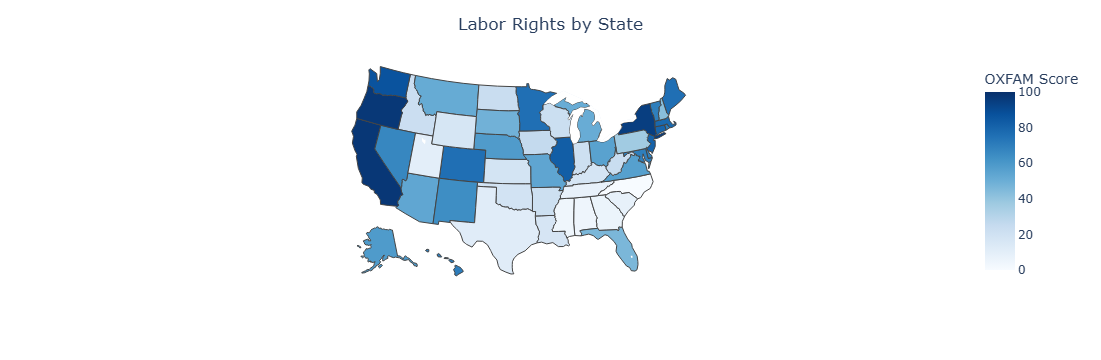

In [121]:
labor_choro = px.choropleth(
    labor_crim_df,
    locations='State Abbreviation',
    locationmode="USA-states",
    color='OXFAM Score',
    scope="usa",
    color_continuous_scale="Blues",
    range_color=(0, 100),
    labels={'Labor Score': 'Labor Score'}
)
labor_choro.update_layout(
    title="Labor Rights by State",
    title_x=0.5
)

labor_choro.show()

### Criminal Justice Reform Map ###

In [115]:
crim_cols = [
    'Death Penalty Status',
    'Felony Disenfranchisement',
    'Cash Bail Reform',
    'Private Prison Ban',
    'Juvenile Justice'
]

labor_crim_df['Criminal Justice Score'] = labor_crim_df[crim_cols].mean(axis=1, skipna=True)

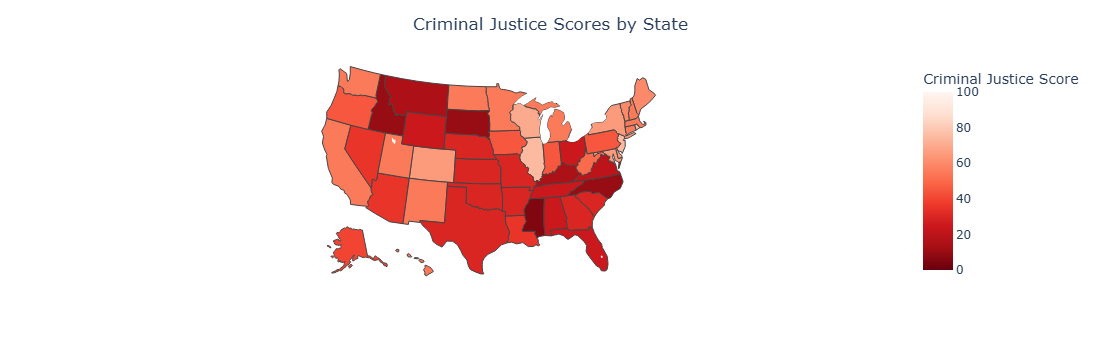

In [119]:
crim_choro = px.choropleth(
    labor_crim_df,
    locations='State Abbreviation',
    locationmode="USA-states",
    color='Criminal Justice Score',
    scope="usa",
    color_continuous_scale="Reds_r",
    range_color=(0, 100),
    labels={'Criminal Justice Score': 'Criminal Justice Score'}
)
crim_choro.update_layout(
    title="Criminal Justice Scores by State",
    title_x=0.5
)

crim_choro.show()

### Radar Charts (Select States, Either Topic, All Dimensions) ###

In [89]:
import plotly.graph_objects as go

In [109]:
california_df = labor_crim_df[labor_crim_df['State'] == 'California']
labor_categories_ca = [
    'OXFAM BSWI Score',
    'Minimum Wage',
    'Paid Family Leave',
    'Paid Sick Leave',
    'Right-to-Work Law',
]


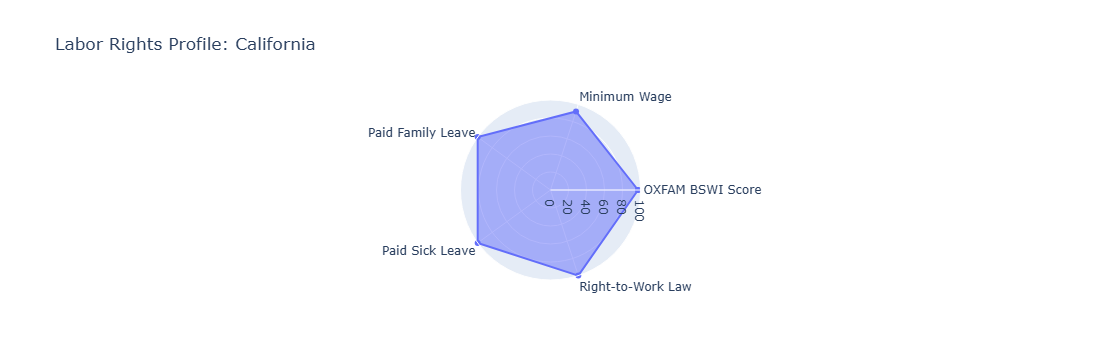

In [110]:
labor_values_ca = [
    california_df['OXFAM Score'].values[0],
    california_df['State Minimum Wage'].values[0],
    california_df['Paid Family Leave'].values[0],
    california_df['Paid Sick Leave'].values[0],
    california_df['Right-to-Work Law'].values[0],
]
labor_values_ca += labor_values_ca[:1]
labor_categories_ca += labor_categories_ca[:1]


ca_labor_radar = go.Figure()

ca_labor_radar.add_trace(go.Scatterpolar(
    r=labor_values_ca,
    theta=labor_categories_ca,
    fill='toself',
    name='California'
))
ca_labor_radar.update_layout(
    polar=dict(
        radialaxis=dict(
            visible=True,
            range=[0, 100]
        )
    ),
    title="Labor Rights Profile: California"
)

ca_labor_radar.show()

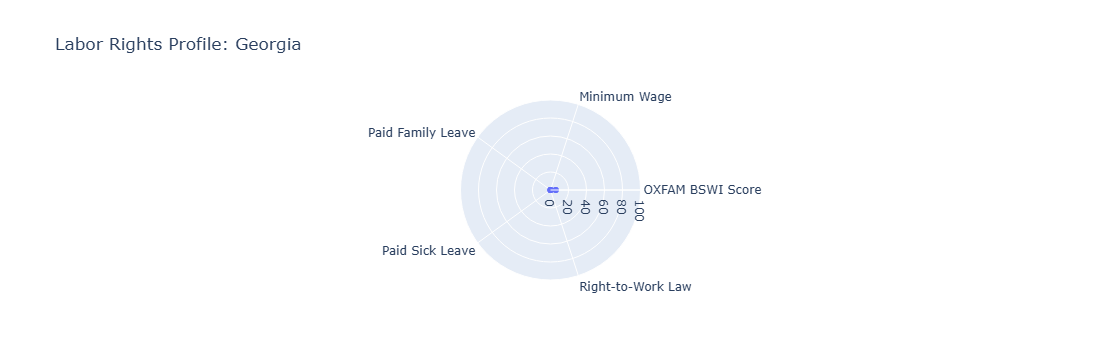

In [111]:
georgia_df = labor_crim_df[labor_crim_df['State'] == 'Georgia']
labor_categories_ga = [
    'OXFAM BSWI Score',
    'Minimum Wage',
    'Paid Family Leave',
    'Paid Sick Leave',
    'Right-to-Work Law',
]

labor_values_ga = [
    georgia_df['OXFAM Score'].values[0],
    georgia_df['State Minimum Wage'].values[0],
    georgia_df['Paid Family Leave'].values[0],
    georgia_df['Paid Sick Leave'].values[0],
    georgia_df['Right-to-Work Law'].values[0],
]
labor_values_ga += labor_values_ga[:1]
labor_categories_ga += labor_categories_ga[:1]


ga_labor_radar = go.Figure()

ga_labor_radar.add_trace(go.Scatterpolar(
    r=labor_values_ga,
    theta=labor_categories_ca,
    fill='toself',
    name='Georgia'
))
ga_labor_radar.update_layout(
    polar=dict(
        radialaxis=dict(
            visible=True,
            range=[0, 100]
        )
    ),
    title="Labor Rights Profile: Georgia"
)

ga_labor_radar.show()

In [125]:
categories_ca = [
    'OXFAM BSWI Score',
    'Minimum Wage',
    'Paid Family Leave',
    'Paid Sick Leave',
    'Right-to-Work Law',
    'Death Penalty Status',
    'Felony Disenfranchisement',
    'Cash Bail Reform',
    'Private Prison Ban',
    'Juvenile Justice'
]

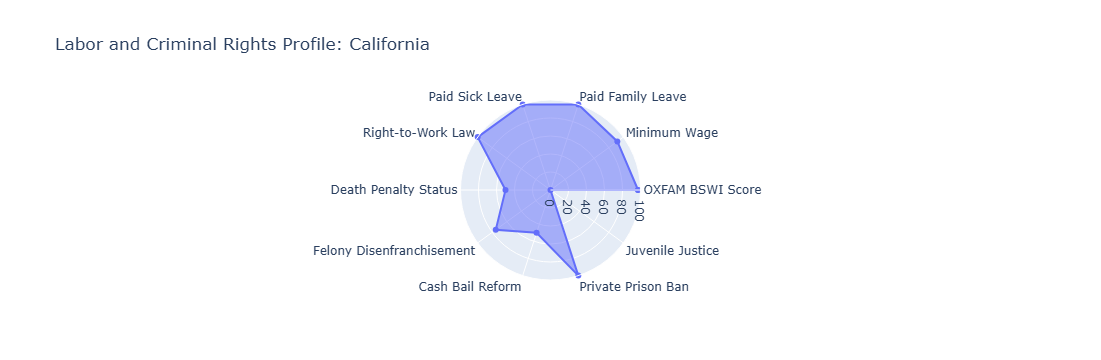

In [126]:
values_ca = [
    california_df['OXFAM Score'].values[0],
    california_df['State Minimum Wage'].values[0],
    california_df['Paid Family Leave'].values[0],
    california_df['Paid Sick Leave'].values[0],
    california_df['Right-to-Work Law'].values[0],
    california_df['Death Penalty Status'].values[0],
    california_df['Felony Disenfranchisement'].values[0],
    california_df['Cash Bail Reform'].values[0],
    california_df['Private Prison Ban'].values[0],
    california_df['Juvenile Justice'].values[0]
]
values_ca += values_ca[:1]
categories_ca += categories_ca[:1]


ca_radar = go.Figure()

ca_radar.add_trace(go.Scatterpolar(
    r=values_ca,
    theta=categories_ca,
    fill='toself',
    name='California'
))
ca_radar.update_layout(
    polar=dict(
        radialaxis=dict(
            visible=True,
            range=[0, 100]
        )
    ),
    title="Labor and Criminal Rights Profile: California"
)

ca_radar.show()

In [128]:
categories_ga = [
    'OXFAM BSWI Score',
    'Minimum Wage',
    'Paid Family Leave',
    'Paid Sick Leave',
    'Right-to-Work Law',
    'Death Penalty Status',
    'Felony Disenfranchisement',
    'Cash Bail Reform',
    'Private Prison Ban',
    'Juvenile Justice'
]

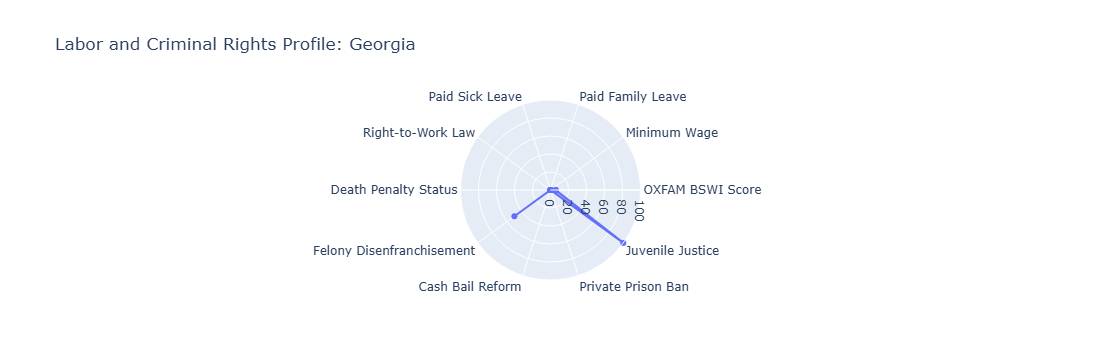

In [129]:
values_ga = [
    georgia_df['OXFAM Score'].values[0],
    georgia_df['State Minimum Wage'].values[0],
    georgia_df['Paid Family Leave'].values[0],
    georgia_df['Paid Sick Leave'].values[0],
    georgia_df['Right-to-Work Law'].values[0],
    georgia_df['Death Penalty Status'].values[0],
    georgia_df['Felony Disenfranchisement'].values[0],
    georgia_df['Cash Bail Reform'].values[0],
    georgia_df['Private Prison Ban'].values[0],
    georgia_df['Juvenile Justice'].values[0]
]
values_ga += values_ga[:1]
categories_ga += categories_ga[:1]


ga_radar = go.Figure()

ga_radar.add_trace(go.Scatterpolar(
    r=values_ga,
    theta=categories_ga,
    fill='toself',
    name='California'
))
ga_radar.update_layout(
    polar=dict(
        radialaxis=dict(
            visible=True,
            range=[0, 100]
        )
    ),
    title="Labor and Criminal Rights Profile: Georgia"
)

ga_radar.show()

In [142]:
wisconsin_df = labor_crim_df[labor_crim_df['State'] == 'Wisconsin']
categories_wi = [
    'OXFAM BSWI Score',
    'Minimum Wage',
    'Paid Family Leave',
    'Paid Sick Leave',
    'Right-to-Work Law',
    'Death Penalty Status',
    'Felony Disenfranchisement',
    'Cash Bail Reform',
    'Private Prison Ban',
    'Juvenile Justice'
]

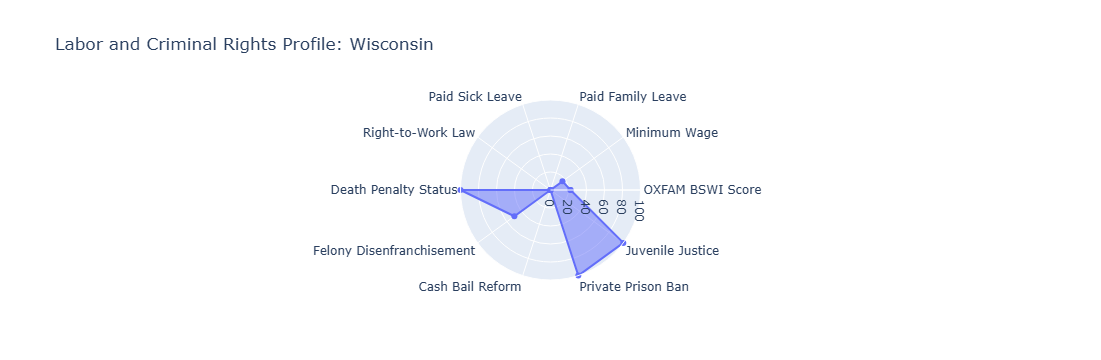

In [143]:
values_wi = [
    wisconsin_df['OXFAM Score'].values[0],
    wisconsin_df['State Minimum Wage'].values[0],
    wisconsin_df['Paid Family Leave'].values[0],
    wisconsin_df['Paid Sick Leave'].values[0],
    wisconsin_df['Right-to-Work Law'].values[0],
    wisconsin_df['Death Penalty Status'].values[0],
    wisconsin_df['Felony Disenfranchisement'].values[0],
    wisconsin_df['Cash Bail Reform'].values[0],
    wisconsin_df['Private Prison Ban'].values[0],
    wisconsin_df['Juvenile Justice'].values[0]
]
values_wi += values_wi[:1]
categories_wi += categories_wi[:1]


wi_radar = go.Figure()

wi_radar.add_trace(go.Scatterpolar(
    r=values_wi,
    theta=categories_wi,
    fill='toself',
    name='Wisconsin'
))
wi_radar.update_layout(
    polar=dict(
        radialaxis=dict(
            visible=True,
            range=[0, 100]
        )
    ),
    title="Labor and Criminal Rights Profile: Wisconsin"
)

wi_radar.show()